# Inspecting the BIDS recording from **legacy (2018-2019) ET data**

Adapted from `7-MREyeTrack_mask_explore-v12.06_pulseq.ipynb`, but stripped down to a **recording-inspection / QC** notebook for the BIDS `*.tsv.gz` + `*.json` produced by `EDF2BIDS_old_data_test.ipynb` from Benedetta Franceschiello's original 3T MR-Eye recordings.

**What is kept** from the mask-explore notebook: loading + metadata, time-series plots (pupil / gaze vs. saccade / fixation), gaze scatter & heatmap before/after cleaning, fine-grained mutually-exclusive event masks, and the velocity diagnostics.

**What is dropped**: the study-specific gaze-region binning (16-/4-point grid, `dot` messages, up/down/left/right/center masks, `mask_clean` filtering, `.mat` mask export). That legacy paradigm is **natural-image free-viewing** (no fixation grid, no `ET: Start routine 'dot'` markers), so region binning does not apply here. This notebook is **read-only** — it writes no masks.

### Kernel
Run with the **`mreyetrack`** conda env.

### Column / header caveats (legacy data)
- `write_bids` writes the TSV **without a header row**, so we read it with `header=None` and take column names from `metadata['Columns']`.
- Columns are the flat BIDS names (`x_coordinate`, `x_velocity`, ...) — **no `eye1_` prefix**, so the rename step from the original notebook is unnecessary.
- The EyeLink `-32768` sentinel marks missing values. In this file **all `fast_*_velocity` columns are 100% sentinel** (never recorded) and `pupil_x/y_coordinate` has a few thousand sentinels — flagged in the QC cell below.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 220, 'display.max_columns', 60)
SENTINEL = -32768  # EyeLink missing-value marker

## 0. Locate the BIDS pair
Point `BIDS_PATH` at the folder holding the converted `*.tsv.gz` / `*.json` (by default, the legacy subject's EDF folder).

In [2]:
BIDS_PATH = Path(
    "/mnt/filer01/MatTechLab/benedetta.franceschiello/_backup_filerch/Benedetta_Franceschiello/"
    "1_MR_Eye_Retina/8_Results/1_Motion_resolved_MR_Eye_3T/1_Motion_Resolved_Anatomical_GRE/"
    "2_Eye_Tracker_Results_Anatomical/2. ET_3T_Data/20181113_exp_jr"
)

tsv_candidates = sorted(BIDS_PATH.glob("*recording-eyetrack_physio.tsv.gz"))
if not tsv_candidates:
    tsv_candidates = sorted(BIDS_PATH.glob("*.tsv.gz"))
if not tsv_candidates:
    raise FileNotFoundError(f"No .tsv.gz found in {BIDS_PATH}")

recording_file = tsv_candidates[0]
json_file = recording_file.with_name(recording_file.name.replace(".tsv.gz", ".json"))
print("recording :", recording_file.name)
print("sidecar   :", json_file.name)

recording : 1s1311_task-fixation_recording-eyetrack_physio.tsv.gz
sidecar   : 1s1311_task-fixation_recording-eyetrack_physio.json


## 1. Load recording + metadata
Headerless TSV → column names come from the sidecar's `Columns` field.

In [3]:
metadata = json.loads(json_file.read_text())
columns = metadata["Columns"]

recording = pd.read_csv(
    recording_file,
    sep="\t",
    header=None,
    names=columns,
    na_values="n/a",
)
print(f"recording: {recording.shape[0]} samples x {recording.shape[1]} columns")
print(f"SamplingFrequency: {metadata['SamplingFrequency']} Hz")
print(f"Recorded eye: {metadata['RecordedEye']} | Method: {metadata['EyeTrackingMethod']}")
recording.head()

recording: 526639 samples x 25 columns
SamplingFrequency: 1000.0 Hz
Recorded eye: right | Method: P-CR


,x_coordinate,y_coordinate,pupil_size,pupil_x_coordinate,pupil_y_coordinate,fixation,saccade,blink,href_x_coordinate,href_y_coordinate,x_velocity,y_velocity,href_x_velocity,href_y_velocity,raw_x_velocity,raw_y_velocity,fast_x_velocity,fast_y_velocity,fast_href_x_velocity,fast_href_y_velocity,fast_raw_x_velocity,fast_raw_y_velocity,screen_ppdeg_x_coordinate,screen_ppdeg_y_coordinate,timestamp
0,407.399994,303.799988,1287.0,-3598.0,-4727.0,0,0,0,84.0,127.0,NaN,NaN,NaN,NaN,NaN,NaN,-32768.0,-32768.0,-32768.0,-32768.0,-32768.0,-32768.0,24.6,24.4,1391009
1,406.899994,304.600006,1289.0,-3594.0,-4721.0,0,0,0,79.0,135.0,NaN,NaN,NaN,NaN,NaN,NaN,-32768.0,-32768.0,-32768.0,-32768.0,-32768.0,-32768.0,24.6,24.4,1391010
2,407.100006,305.399994,1290.0,-3595.0,-4715.0,0,0,0,81.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,-32768.0,-32768.0,-32768.0,-32768.0,-32768.0,-32768.0,24.6,24.4,1391011
3,408.500000,305.899994,1290.0,-3607.0,-4712.0,0,0,0,96.0,149.0,NaN,NaN,NaN,NaN,NaN,NaN,-32768.0,-32768.0,-32768.0,-32768.0,-32768.0,-32768.0,24.6,24.4,1391012
4,409.899994,305.299988,1289.0,-3619.0,-4716.0,0,0,0,111.0,143.0,NaN,NaN,NaN,NaN,NaN,NaN,-32768.0,-32768.0,-32768.0,-32768.0,-32768.0,-32768.0,24.6,24.4,1391013


## 2. Metadata & calibration summary

In [4]:
for k in [
    "Manufacturer", "ManufacturersModelName", "SoftwareVersion",
    "RecordedEye", "SamplingFrequency", "EyeTrackingMethod",
    "CalibrationCount", "CalibrationType", "CalibrationResultQuality",
    "AverageCalibrationError", "MaximalCalibrationError",
    "PupilFitMethod", "PupilThreshold", "CornealReflectionThreshold",
    "ScreenAOIDefinition", "StartTime", "StopTime",
]:
    print(f"{k:28s}: {metadata.get(k)}")

print("\nValidationPosition:", metadata.get("ValidationPosition"))
print("ValidationErrors  :", metadata.get("ValidationErrors"))
print(f"\nLoggedMessages: {len(metadata.get('LoggedMessages', []))} entries (first 10):")
for m in metadata.get("LoggedMessages", [])[:10]:
    print("   ", m)

Manufacturer                : SR Research
ManufacturersModelName      : EyeLink CL-OC
SoftwareVersion             : Eyelink 1000 v4.1594
RecordedEye                 : right
SamplingFrequency           : 1000.0
EyeTrackingMethod           : P-CR
CalibrationCount            : 1
CalibrationType             : HV5
CalibrationResultQuality    : GOOD
AverageCalibrationError     : 0.37
MaximalCalibrationError     : 0.81
PupilFitMethod              : ellipse
PupilThreshold              : 138
CornealReflectionThreshold  : 229
ScreenAOIDefinition         : ['square', [0, 799, 0, 599]]
StartTime                   : 525.453
StopTime                    : 5.017

ValidationPosition: [[400, 300], [400, 51], [400, 548], [48, 300], [751, 300]]
ValidationErrors  : [[0.34, [0.5, 8.5]], [0.56, [2.0, -13.8]], [0.15, [-2.2, 3.0]], [0.81, [-19.9, -4.7]], [0.08, [-1.9, 0.0]]]

LoggedMessages: 1070 entries (first 10):
    [1031582, 'DISPLAY_COORDS 0 0 799 599']
    [1031582, 'RETRACE_INTERVAL  16.6270302893']
  

## 3. Recording QC overview
Dtypes, summary stats, missing values, `-32768` sentinels, and whole-column flags (columns that are entirely NaN or entirely sentinel carry no information).

In [5]:
n = len(recording)
nan_counts = recording.isna().sum()
sentinel_counts = (recording == SENTINEL).sum()

qc = pd.DataFrame({
    "dtype": recording.dtypes.astype(str),
    "n_nan": nan_counts,
    "pct_nan": (100 * nan_counts / n).round(2),
    "n_sentinel": sentinel_counts,
    "pct_sentinel": (100 * sentinel_counts / n).round(2),
})
# a column is uninformative if every sample is NaN or sentinel
qc["all_missing"] = (nan_counts + sentinel_counts) >= n
qc

,dtype,n_nan,pct_nan,n_sentinel,pct_sentinel,all_missing
x_coordinate,float64,2701,0.51,0,0.00,False
y_coordinate,float64,2701,0.51,0,0.00,False
pupil_size,float64,2701,0.51,0,0.00,False
pupil_x_coordinate,float64,0,0.00,1760,0.33,False
pupil_y_coordinate,float64,0,0.00,1760,0.33,False
fixation,int64,0,0.00,0,0.00,False
saccade,int64,0,0.00,0,0.00,False
blink,int64,0,0.00,0,0.00,False
href_x_coordinate,float64,0,0.00,0,0.00,False
href_y_coordinate,float64,0,0.00,0,0.00,False


In [6]:
dead_cols = qc.index[qc["all_missing"]].tolist()
print("Columns with NO usable data (all NaN/sentinel):")
for c in dead_cols:
    print("   ", c)
print(f"\n{len(dead_cols)} of {recording.shape[1]} columns are unusable in this recording.")

print("\nSummary stats for usable numeric columns:")
usable = [c for c in recording.columns if c not in dead_cols]
recording[usable].describe().T

Columns with NO usable data (all NaN/sentinel):
    fast_x_velocity
    fast_y_velocity
    fast_href_x_velocity
    fast_href_y_velocity
    fast_raw_x_velocity
    fast_raw_y_velocity

6 of 25 columns are unusable in this recording.

Summary stats for usable numeric columns:


,count,mean,std,min,25%,50%,75%,max
x_coordinate,523938.0,4.234629e+02,191.426198,-4.520000e+02,3.091000e+02,4.147000e+02,5.353000e+02,1.510700e+03
y_coordinate,523938.0,2.955770e+02,145.418144,-6.120000e+01,2.157000e+02,3.010000e+02,3.799000e+02,1.192200e+03
pupil_size,523938.0,1.597558e+03,277.665308,1.200000e+02,1.419000e+03,1.583000e+03,1.783000e+03,4.013000e+03
pupil_x_coordinate,526639.0,-3.877598e+03,2332.490938,-3.276800e+04,-4.710000e+03,-3.665000e+03,-2.794000e+03,3.854000e+03
pupil_y_coordinate,526639.0,-4.788931e+03,2017.043736,-3.276800e+04,-5.332000e+03,-4.749000e+03,-4.077000e+03,2.258400e+04
fixation,526639.0,9.460048e-01,0.226009,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
saccade,526639.0,5.208881e-02,0.222206,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
blink,526639.0,8.106122e-03,0.089668,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
href_x_coordinate,526639.0,2.134068e+02,2113.364582,-8.886000e+03,-9.820000e+02,1.540000e+02,1.444000e+03,1.165000e+04
href_y_coordinate,526639.0,-1.144634e+01,1654.033476,-7.936000e+03,-8.310000e+02,9.000000e+01,9.340000e+02,9.280000e+03


In [7]:
# Timing continuity: EyeLink timestamps should be a contiguous 1 ms grid
ts = recording["timestamp"].to_numpy()
dts = np.diff(ts)
duration_s = (ts[-1] - ts[0]) / metadata["SamplingFrequency"]
print(f"Duration: {duration_s:.1f} s  ({len(recording)} samples)")
print(f"timestamp step: min={dts.min()}, median={np.median(dts):.0f}, max={dts.max()}")
gaps = int((dts != 1).sum())
print(f"Non-unit steps (gaps/duplicates): {gaps}")
print(f"Duplicated timestamps: {int(recording['timestamp'].duplicated().sum())}")

Duration: 530.4 s  (526639 samples)
timestamp step: min=1, median=1, max=63
Non-unit steps (gaps/duplicates): 105
Duplicated timestamps: 0


## 4. Time axis

In [8]:
t_axis = (recording.timestamp.values - recording.timestamp.values[0]) / metadata["SamplingFrequency"]
print(f"Recording spans 0 -> {t_axis[-1]:.1f} s")

# Window (seconds) used by the zoomed time-series plots below
WIN = (100.0, 120.0)

Recording spans 0 -> 530.4 s


## 5. Time-series: pupil / gaze vs. events
Same idioms as the mask-explore notebook (flat column names).

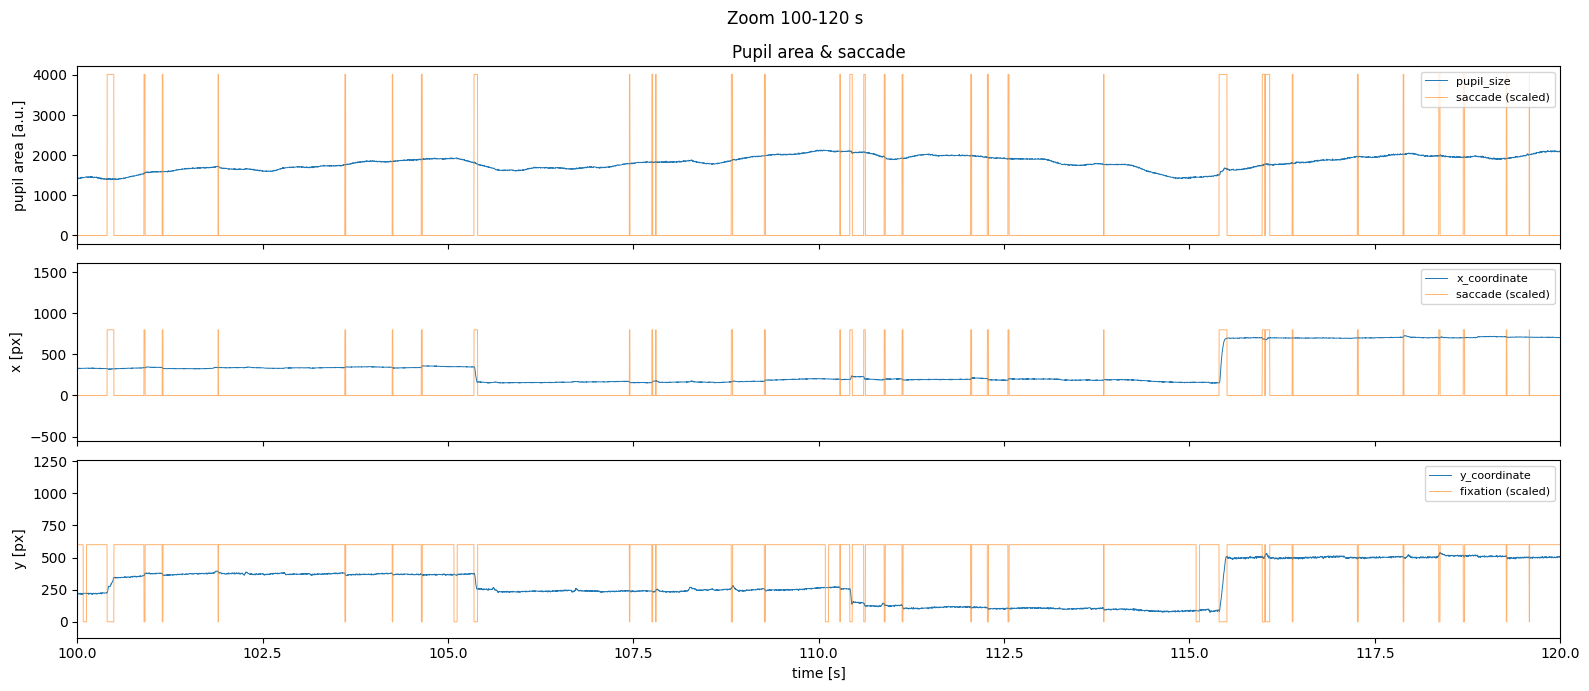

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(16, 7), sharex=True)

axes[0].plot(t_axis, recording["pupil_size"].values, lw=0.7, label="pupil_size")
axes[0].plot(t_axis, recording["saccade"].values * recording["pupil_size"].max(),
             lw=0.7, alpha=0.6, label="saccade (scaled)")
axes[0].set_ylabel("pupil area [a.u.]")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Pupil area & saccade")

axes[1].plot(t_axis, recording["x_coordinate"].values, lw=0.7, label="x_coordinate")
axes[1].plot(t_axis, recording["saccade"].values * 800, lw=0.7, alpha=0.6, label="saccade (scaled)")
axes[1].set_ylabel("x [px]")
axes[1].legend(loc="upper right", fontsize=8)

axes[2].plot(t_axis, recording["y_coordinate"].values, lw=0.7, label="y_coordinate")
axes[2].plot(t_axis, recording["fixation"].values * 600, lw=0.7, alpha=0.6, label="fixation (scaled)")
axes[2].set_ylabel("y [px]")
axes[2].set_xlabel("time [s]")
axes[2].legend(loc="upper right", fontsize=8)

for ax in axes:
    ax.set_xlim(*WIN)
fig.suptitle(f"Zoom {WIN[0]:.0f}-{WIN[1]:.0f} s")
plt.tight_layout()
plt.show()

## 6. Gaze scatter: raw vs. cleaned (blinks + saccades removed)
Reuses the `eliminate_blink` / `preserve_fixation` idea from the original notebook, but non-destructively on a copy.

raw valid samples   : 523938
cleaned valid samples: 498203  (removed blink or non-fixation)


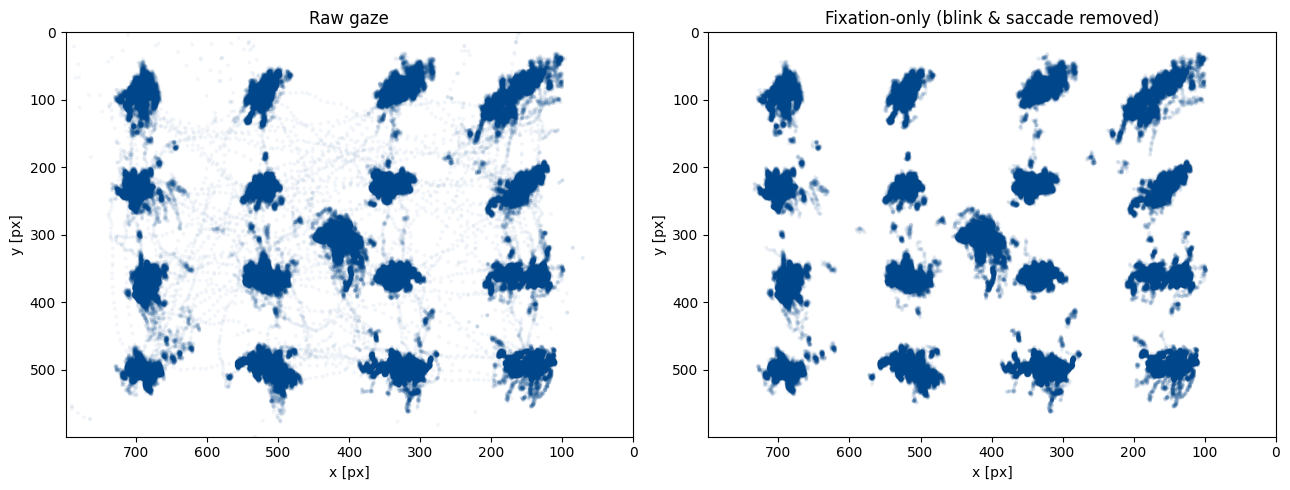

In [10]:
screen_w = metadata["ScreenAOIDefinition"][1][1]
screen_h = metadata["ScreenAOIDefinition"][1][3]

coor_raw = recording[["x_coordinate", "y_coordinate"]].copy()

# cleaned = drop samples flagged as blink or not-fixation (set to NaN, don't reindex)
coor_clean = coor_raw.copy()
drop = (recording["blink"] > 0) | (recording["fixation"] < 1)
coor_clean.loc[drop, ["x_coordinate", "y_coordinate"]] = np.nan
print(f"raw valid samples   : {coor_raw.dropna().shape[0]}")
print(f"cleaned valid samples: {coor_clean.dropna().shape[0]}  (removed blink or non-fixation)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, title in [
    (axes[0], coor_raw, "Raw gaze"),
    (axes[1], coor_clean, "Fixation-only (blink & saccade removed)"),
]:
    ax.scatter(data["x_coordinate"], data["y_coordinate"],
               s=8, c="#00468b", alpha=0.05, edgecolors="none")
    ax.set_xlim(0, screen_w); ax.set_ylim(0, screen_h)
    ax.invert_yaxis(); ax.invert_xaxis()
    ax.set_xlabel("x [px]"); ax.set_ylabel("y [px]")
    ax.set_title(title)
plt.tight_layout()
plt.show()

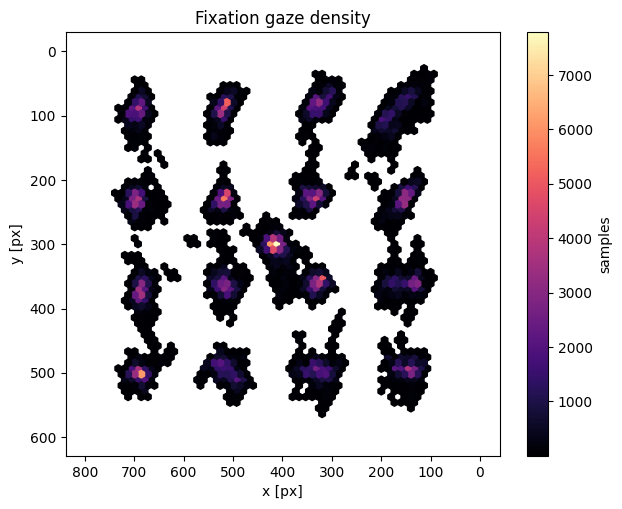

In [11]:
# 2D gaze density (fixation-only), clipped to the screen
d = coor_clean.dropna()
d = d[(d.x_coordinate.between(0, screen_w)) & (d.y_coordinate.between(0, screen_h))]
fig, ax = plt.subplots(figsize=(7, 5.5))
hb = ax.hexbin(d.x_coordinate, d.y_coordinate, gridsize=60,
               extent=(0, screen_w, 0, screen_h), cmap="magma", mincnt=1)
ax.invert_yaxis(); ax.invert_xaxis()
ax.set_xlabel("x [px]"); ax.set_ylabel("y [px]")
ax.set_title("Fixation gaze density")
fig.colorbar(hb, ax=ax, label="samples")
plt.show()

## 7. Event statistics
Per-sample flag totals, plus event *counts* and *durations* recovered from the flag transitions.

In [12]:
def event_segments(flag):
    """Return list of (start_idx, end_idx_exclusive) runs where flag==1."""
    f = flag.to_numpy().astype(int)
    edges = np.diff(np.concatenate([[0], f, [0]]))
    starts = np.where(edges == 1)[0]
    ends = np.where(edges == -1)[0]
    return list(zip(starts, ends))

fs = metadata["SamplingFrequency"]
rows = []
for name in ["fixation", "saccade", "blink"]:
    segs = event_segments(recording[name])
    durs = np.array([(e - s) for s, e in segs]) / fs * 1000  # ms
    rows.append({
        "event": name,
        "n_samples_flagged": int(recording[name].sum()),
        "pct_of_recording": round(100 * recording[name].sum() / n, 2),
        "n_events": len(segs),
        "median_dur_ms": round(float(np.median(durs)), 1) if len(durs) else np.nan,
        "mean_dur_ms": round(float(np.mean(durs)), 1) if len(durs) else np.nan,
        "max_dur_ms": round(float(np.max(durs)), 1) if len(durs) else np.nan,
    })
pd.DataFrame(rows).set_index("event")

,n_samples_flagged,pct_of_recording,n_events,median_dur_ms,mean_dur_ms,max_dur_ms
event,,,,,,
fixation,498203,94.60,1119,273.0,445.2,3684.0
saccade,27432,5.21,1019,15.0,26.9,1030.0
blink,4269,0.81,24,136.5,177.9,1030.0


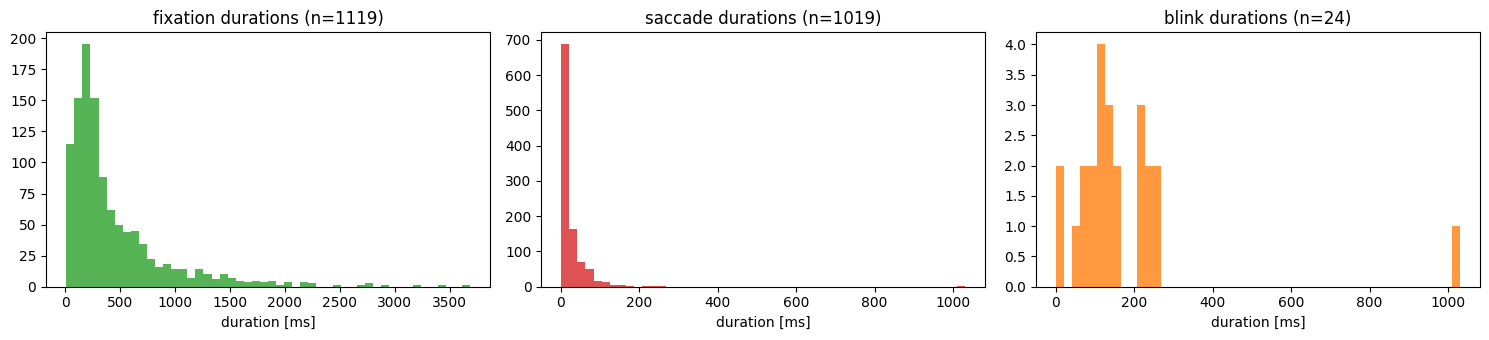

In [13]:
# Duration histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, name, color in zip(axes, ["fixation", "saccade", "blink"],
                            ["#2ca02c", "#d62728", "#ff7f0e"]):
    segs = event_segments(recording[name])
    durs = np.array([(e - s) for s, e in segs]) / fs * 1000
    ax.hist(durs, bins=50, color=color, alpha=0.8)
    ax.set_title(f"{name} durations (n={len(durs)})")
    ax.set_xlabel("duration [ms]")
plt.tight_layout()
plt.show()

## 8. Fine-grained mutually-exclusive event masks
Ported from the mask-explore notebook (priority **blink > saccade > fixation > tracking-loss**), aligned to the whole recording (no MRI-window offset for legacy free-viewing data).

In [14]:
orig_nan = recording["x_coordinate"].isna() | recording["y_coordinate"].isna()

is_blink        = recording["blink"].astype(bool)
is_saccade_only = recording["saccade"].astype(bool) & ~is_blink
is_fixation_ok  = recording["fixation"].astype(bool) & ~is_saccade_only & ~is_blink & ~orig_nan
is_tracking_loss = ~is_blink & ~is_saccade_only & ~is_fixation_ok

masks = {
    "fixation_ok":   is_fixation_ok.to_numpy(),
    "saccade_only":  is_saccade_only.to_numpy(),
    "blink_event":   is_blink.to_numpy(),
    "tracking_loss": is_tracking_loss.to_numpy(),
}
summary = pd.DataFrame({
    "n_samples": {k: int(v.sum()) for k, v in masks.items()},
    "pct": {k: round(100 * v.sum() / n, 2) for k, v in masks.items()},
})
assert sum(summary["n_samples"]) == n, "masks must partition the recording"
summary

,n_samples,pct
fixation_ok,498203,94.60
saccade_only,23163,4.40
blink_event,4269,0.81
tracking_loss,1004,0.19


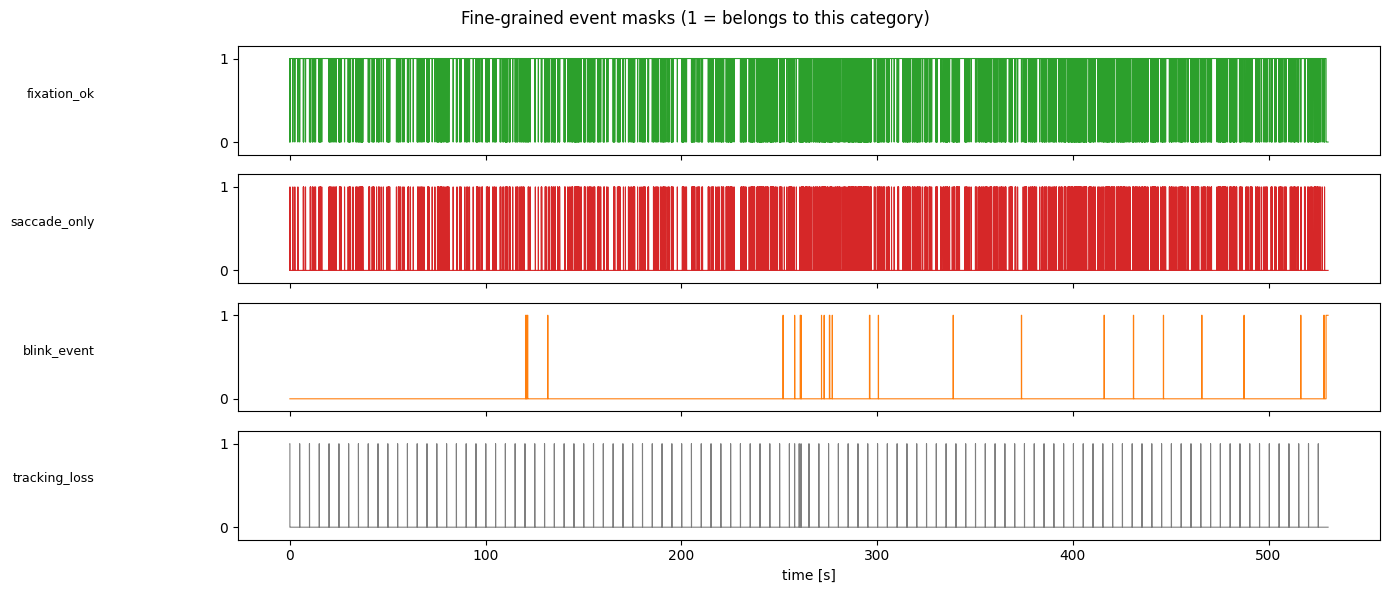

In [15]:
colors = {"fixation_ok": "#2ca02c", "saccade_only": "#d62728",
          "blink_event": "#ff7f0e", "tracking_loss": "#7f7f7f"}
fig, axes = plt.subplots(4, 1, figsize=(14, 6), sharex=True)
for ax, (label, mask) in zip(axes, masks.items()):
    ax.step(t_axis, mask, where="post", color=colors[label], lw=0.8)
    ax.set_ylabel(label, rotation=0, ha="right", labelpad=90, fontsize=9)
    ax.set_ylim(-0.15, 1.15); ax.set_yticks([0, 1])
axes[-1].set_xlabel("time [s]")
fig.suptitle("Fine-grained event masks (1 = belongs to this category)")
plt.tight_layout()
plt.show()

## 9. Velocity diagnostics
Ported from the mask-explore notebook. Uses the flat `x_velocity` / `y_velocity` (gaze, deg/s) and `href_*_velocity` (calibration-independent) columns. The `fast_*_velocity` columns are all sentinel here and are skipped automatically.

In [16]:
SPEED_THRESHOLD_DEG_S = 30.0  # SR Research default saccade velocity threshold

def speed(cx, cy):
    if cx not in recording or cy not in recording:
        return None
    a = recording[cx].to_numpy(); b = recording[cy].to_numpy()
    if np.all(np.isnan(a)) or np.all(a == SENTINEL):
        return None
    return np.sqrt(a ** 2 + b ** 2)

gaze_speed = speed("x_velocity", "y_velocity")
href_speed = speed("href_x_velocity", "href_y_velocity")

if gaze_speed is None:
    print("No usable gaze-velocity columns; skipping velocity diagnostics.")
else:
    is_moving = gaze_speed > SPEED_THRESHOLD_DEG_S
    known = ~np.isnan(gaze_speed)
    print(f"Samples with known gaze velocity: {known.sum()} / {n}")
    print(f"Samples above {SPEED_THRESHOLD_DEG_S:.0f} deg/s (gaze): {int((is_moving & known).sum())}")
    if href_speed is not None:
        both = known & ~np.isnan(href_speed)
        r = np.corrcoef(gaze_speed[both], href_speed[both])[0, 1]
        print(f"gaze vs. href speed correlation: {r:.4f}")

Samples with known gaze velocity: 521360 / 526639
Samples above 30 deg/s (gaze): 25228
gaze vs. href speed correlation: 1.0000


fixation_ok   :   1.6% of velocity-known samples are 'moving' (>thr); velocity unknown in  0.2% of them
saccade_only  :  71.9% of velocity-known samples are 'moving' (>thr); velocity unknown in  0.2% of them


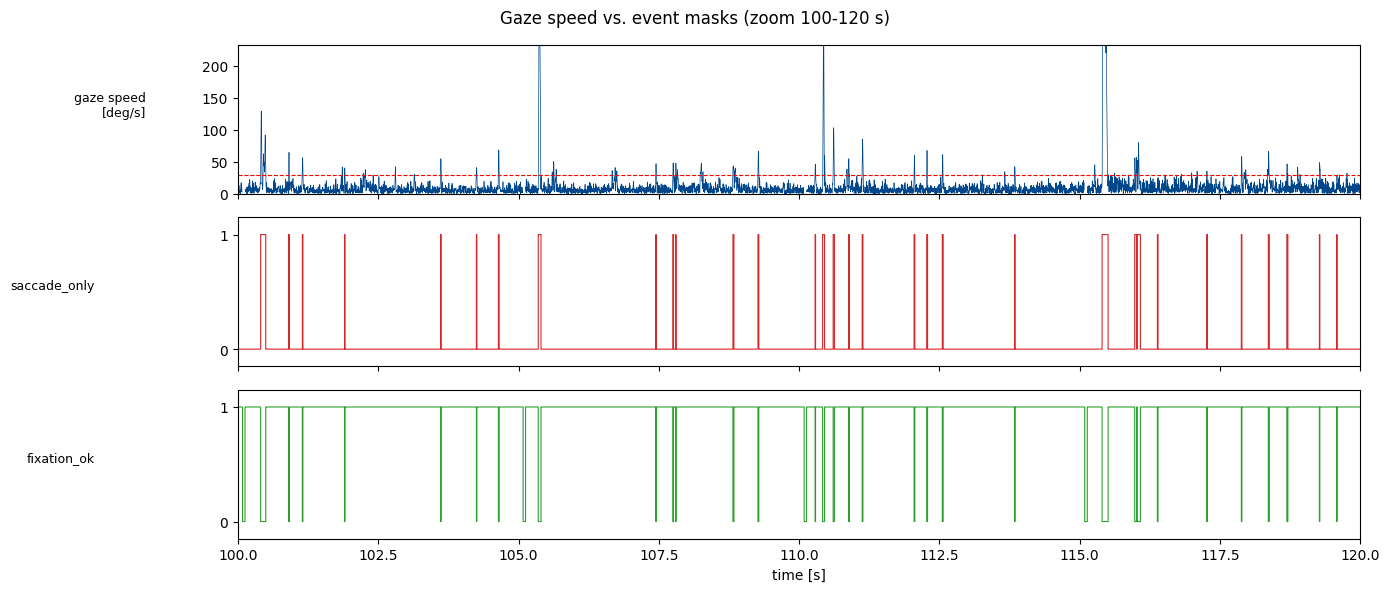

In [17]:
if gaze_speed is not None:
    # Agreement between the velocity threshold and the onboard event flags
    known = ~np.isnan(gaze_speed)
    is_moving = gaze_speed > SPEED_THRESHOLD_DEG_S
    for label in ["fixation_ok", "saccade_only"]:
        m = masks[label].astype(bool)
        k = m & known
        if k.sum():
            moving_rate = 100 * (is_moving & k).sum() / k.sum()
            print(f"{label:14s}: {moving_rate:5.1f}% of velocity-known samples are 'moving' (>thr); "
                  f"velocity unknown in {100*(m & ~known).sum()/max(m.sum(),1):4.1f}% of them")

    fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(t_axis, gaze_speed, color="#00468b", lw=0.5)
    axes[0].axhline(SPEED_THRESHOLD_DEG_S, color="r", ls="--", lw=0.8)
    axes[0].set_ylabel("gaze speed\n[deg/s]", rotation=0, ha="right", labelpad=40, fontsize=9)
    axes[0].set_ylim(0, np.nanpercentile(gaze_speed, 99.5))
    for ax, label in zip(axes[1:], ["saccade_only", "fixation_ok"]):
        ax.step(t_axis, masks[label], where="post", color=colors[label], lw=0.8)
        ax.set_ylabel(label, rotation=0, ha="right", labelpad=90, fontsize=9)
        ax.set_ylim(-0.15, 1.15); ax.set_yticks([0, 1])
    axes[-1].set_xlabel("time [s]")
    for ax in axes:
        ax.set_xlim(*WIN)
    fig.suptitle(f"Gaze speed vs. event masks (zoom {WIN[0]:.0f}-{WIN[1]:.0f} s)")
    plt.tight_layout()
    plt.show()

## Summary
The BIDS recording from the legacy EDF is fully inspectable: gaze x/y, pupil size, HREF, gaze/HREF/raw velocities, per-sample fixation/saccade/blink flags, and event durations all check out. Notes carried over from the QC cell:
- **`fast_*_velocity` columns are 100% sentinel** (never recorded on this device/config) — ignore them.
- A few thousand `pupil_x/y_coordinate` samples are sentinel; gaze `x/y_coordinate` has a small NaN fraction (tracking loss / blinks).
- This is **free-viewing**, not the fixation-grid paradigm, so gaze-direction binning from the mask-explore notebook is intentionally omitted.